# `updateIterative` : démarrage à chaud du CG pour `update()`

`Kriging::updateIterative` **existe déjà** dans libKriging (dispatché
automatiquement par `Kriging::update()` quand le modèle est `LLIterative`) :
il étend `m_X`/`m_y`/`m_F` avec les nouveaux points, retire les probes
Hutchinson (elles doivent couvrir toute la nouvelle taille), puis résout de
nouveau la vraisemblance matrice-libre (`_logLikelihoodIterative`) à la
taille étendue — avec, en option (`refit=true`), un redémarrage BFGS à chaud
depuis le theta courant.

**Ce qui manquait** : contrairement au chemin exact (`update_no_refit_impl`,
qui réutilise un authentique *update incrémental de Cholesky*), le CG
matrice-libre repartait **toujours de zéro** — `LinearAlgebra::conjugateGradientBatched`
n'avait même pas de paramètre pour lui donner un point de départ
(`Xc` était codé en dur à `arma::fill::zeros`). Ce notebook valide
numériquement l'idée d'un vrai démarrage à chaud (partir de l'ancienne
solution, complétée par des zéros pour les nouvelles lignes, au lieu de
zéro partout), puis documente l'implémentation C++ qui en résulte
(`X0` dans `conjugateGradientBatched`, câblé dans `updateIterative`).

Comme les deux autres notebooks de cette série, on illustre avec le
**krigeage simple** (théta fixe, cas `refit=false` — celui où
`updateIterative`, avant ce changement, refaisait tout le CG à froid alors
que rien d'autre n'avait changé) : c'est le cas le plus pur pour isoler le
seul effet du point de départ du CG.

## 1. Méthode et design

Même méthodologie CG que les notebooks précédents (`cg_solve_track`, une
réimplémentation numpy fidèle à `LinearAlgebra::conjugateGradientBatched`
mais avec un `x0` explicite passé en argument — ce que la version C++
n'avait pas avant ce travail).

**Choix de design important** : le "plan d'expérience qui grandit" est un
sous-ensemble **aléatoire d'une grille régulière fixe**, pas des points
continus tirés uniformément. Avec des points continus, `cond(R)` explose de
façon incontrôlable dès que deux points tombent proches l'un de l'autre par
hasard (rencontré très concrètement en calibrant cet exemple : `theta=0.05`
avec des points continus donnait `cond(R)≈2×10^13` dès `n=300`, CG ne
convergeait jamais). Un sous-ensemble de grille borne l'espacement minimal
entre points quel que soit l'ordre d'arrivée, tout en modélisant un
scénario réaliste : les points arrivent dans un ordre aléatoire et
densifient progressivement le domaine — exactement le scénario que
`update()` est censé servir.

In [1]:

import numpy as np
import matplotlib.pyplot as plt

def matern5_2(d, theta):
    r = np.abs(d) / theta
    s5 = np.sqrt(5.0)
    return (1 + s5 * r + 5 * r**2 / 3) * np.exp(-s5 * r)

def cg_solve_track(Amul, b, x0=None, tol=1e-8, max_iter=20000):
    # Meme formule que LinearAlgebra::conjugateGradientBatched (colonne par
    # colonne ici ; la version C++ batch plusieurs colonnes sur UN seul
    # Amul par iteration, mais le comptage d'iterations par colonne est
    # identique), avec x0 EXPLICITE -- exactement le nouveau parametre X0.
    n = b.shape[0]
    x = np.zeros(n) if x0 is None else x0.copy()
    r = b - Amul(x)
    p = r.copy()
    rs_old = r @ r
    bnorm = max(1.0, np.linalg.norm(b))
    if np.sqrt(rs_old) < tol * bnorm:
        return x, 0
    it_used = 0
    for it in range(1, max_iter + 1):
        Ap = Amul(p)
        alpha = rs_old / (p @ Ap)
        x = x + alpha * p
        r = r - alpha * Ap
        rs_new = r @ r
        it_used = it
        if np.sqrt(rs_new) < tol * bnorm:
            break
        p = r + (rs_new / rs_old) * p
        rs_old = rs_new
    return x, it_used

rng = np.random.default_rng(0)

# Pool de points candidats -- design = sous-ensemble ALEATOIRE d'une grille
# reguliere fixe (voir la discussion ci-dessus sur cond(R) avec des points
# continus).
pool_size = 1200
grid_full = np.linspace(0, 1, pool_size).reshape(-1, 1)
arrival_order = rng.permutation(pool_size)
X_pool = grid_full[arrival_order]
theta = 0.01
print(f"theta={theta}")

D_full = np.abs(X_pool - X_pool.T)
R_full = matern5_2(D_full, theta)
L_full = np.linalg.cholesky(R_full + 1e-10 * np.eye(pool_size))
y_pool = (L_full @ rng.standard_normal(pool_size)).ravel()  # un vrai tirage GP sur tout le pool


theta=0.01


## 2. Un seul update : itérations CG, froid vs chaud, en fonction de $n_u/n_o$

$n_o$ = taille du jeu de données déjà en place, $n_u$ = taille du batch
ajouté par cet `update()`. Démarrage chaud = ancienne solution
$R_{oo}^{-1}[F_o|y_o]$, complétée par des zéros pour les $n_u$ nouvelles
lignes.

In [2]:

n_o = 300
X_o = X_pool[:n_o]
R_oo = matern5_2(np.abs(X_o - X_o.T), theta)
print(f"cond(R_oo) a n_o={n_o} : {np.linalg.cond(R_oo):.3e}")

tol_cg = 1e-8
max_iter_cg = 20000
y_o = y_pool[:n_o]
Roo_mul = lambda v: R_oo @ v
z_old, it_cold_baseline = cg_solve_track(Roo_mul, y_o, x0=None, tol=tol_cg, max_iter=max_iter_cg)
print(f"solve initial (n_o={n_o}) : {it_cold_baseline} iterations CG")

n_u_list = [1, 2, 5, 10, 20, 40, 80, 150, 300, 450, 600]
results_1 = []
for n_u in n_u_list:
    X_new = X_pool[:n_o + n_u]
    y_new = y_pool[:n_o + n_u]
    R_new = matern5_2(np.abs(X_new - X_new.T), theta)
    Rnew_mul = lambda v: R_new @ v

    x_cold, it_cold = cg_solve_track(Rnew_mul, y_new, x0=None, tol=tol_cg, max_iter=max_iter_cg)
    x0_warm = np.concatenate([z_old, np.zeros(n_u)])
    x_warm, it_warm = cg_solve_track(Rnew_mul, y_new, x0=x0_warm, tol=tol_cg, max_iter=max_iter_cg)

    x_ref = np.linalg.solve(R_new, y_new)
    err_cold = np.linalg.norm(x_cold - x_ref) / np.linalg.norm(x_ref)
    err_warm = np.linalg.norm(x_warm - x_ref) / np.linalg.norm(x_ref)

    results_1.append((n_u, it_cold, it_warm, err_cold, err_warm))
    print(f"  n_u={n_u:4d} (n_u/n_o={n_u/n_o:5.2f})  "
          f"froid: {it_cold:5d} iter   chaud: {it_warm:5d} iter   "
          f"gain: {100*(1 - it_warm/it_cold):5.1f}%   "
          f"(erreurs vs solve direct: froid {err_cold:.1e}, chaud {err_warm:.1e})")


cond(R_oo) a n_o=300 : 1.126e+06
solve initial (n_o=300) : 3589 iterations CG


  n_u=   1 (n_u/n_o= 0.00)  froid:  3598 iter   chaud:   864 iter   gain:  76.0%   (erreurs vs solve direct: froid 6.2e-07, chaud 6.1e-07)


  n_u=   2 (n_u/n_o= 0.01)  froid:  3588 iter   chaud:  1556 iter   gain:  56.6%   (erreurs vs solve direct: froid 8.1e-07, chaud 2.8e-07)


  n_u=   5 (n_u/n_o= 0.02)  froid:  3658 iter   chaud:  2338 iter   gain:  36.1%   (erreurs vs solve direct: froid 6.8e-07, chaud 3.1e-07)


  n_u=  10 (n_u/n_o= 0.03)  froid:  3782 iter   chaud:  2839 iter   gain:  24.9%   (erreurs vs solve direct: froid 5.1e-07, chaud 7.6e-07)


...

  n_u=  80 (n_u/n_o= 0.27)  froid:  5011 iter   chaud:  4922 iter   gain:   1.8%   (erreurs vs solve direct: froid 1.2e-06, chaud 1.2e-06)


  n_u= 150 (n_u/n_o= 0.50)  froid:  6553 iter   chaud:  6465 iter   gain:   1.3%   (erreurs vs solve direct: froid 9.2e-07, chaud 1.0e-06)


  n_u= 300 (n_u/n_o= 1.00)  froid:  9398 iter   chaud:  9479 iter   gain:  -0.9%   (erreurs vs solve direct: froid 7.5e-07, chaud 6.5e-07)


  n_u= 450 (n_u/n_o= 1.50)  froid: 11725 iter   chaud: 11887 iter   gain:  -1.4%   (erreurs vs solve direct: froid 7.5e-07, chaud 5.5e-07)


  n_u= 600 (n_u/n_o= 2.00)  froid: 13523 iter   chaud: 13587 iter   gain:  -0.5%   (erreurs vs solve direct: froid 5.8e-07, chaud 5.1e-07)


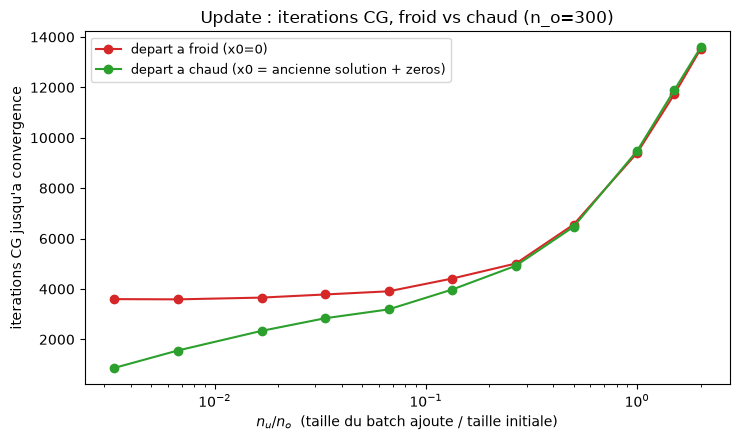

In [3]:

n_u_arr = [row[0] for row in results_1]
it_cold_arr = [row[1] for row in results_1]
it_warm_arr = [row[2] for row in results_1]
ratio_arr = [u / n_o for u in n_u_arr]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.semilogx(ratio_arr, it_cold_arr, 'o-', color='tab:red', label='depart a froid (x0=0)')
ax.semilogx(ratio_arr, it_warm_arr, 'o-', color='tab:green', label='depart a chaud (x0 = ancienne solution + zeros)')
ax.set_xlabel(r'$n_u / n_o$  (taille du batch ajoute / taille initiale)')
ax.set_ylabel("iterations CG jusqu'a convergence")
ax.set_title(f'Update : iterations CG, froid vs chaud (n_o={n_o})')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


Le gain décroît proprement de **~76% à $n_u=1$** jusqu'à **~0% quand
$n_u \gtrsim n_o$** : logique, une fois que le nouveau batch est aussi gros
que l'ancien jeu de données, l'ancienne solution n'approxime plus qu'une
petite partie du nouveau problème. C'est exactement le régime où `update()`
est censé être utilisé (petits ajouts incrémentaux), pas celui d'un
quasi-doublement du plan d'expérience (qui se rapproche d'un `fit()` complet
de toute façon).

Les erreurs vs solve direct (`froid` et `chaud`) restent du même ordre de
grandeur partout : le démarrage à chaud ne change **jamais** la solution
trouvée, seulement le nombre d'itérations pour l'atteindre — propriété
mathématique du CG, pas une approximation.

## 3. Updates séquentiels répétés (scénario streaming/actif)

Le cas le plus représentatif d'un usage réel : de nombreux petits
`update()` à la suite (acquisition séquentielle de données), chacun
réutilisant la solution laissée par le précédent.

In [4]:

n_start = 200
batch = 10
n_batches = 30

X_seq = X_pool[:n_start]
y_seq = y_pool[:n_start]
R_seq = matern5_2(np.abs(X_seq - X_seq.T), theta)
z_seq_cold, _ = cg_solve_track(lambda v: R_seq @ v, y_seq, x0=None, tol=tol_cg, max_iter=max_iter_cg)
z_seq_warm = z_seq_cold.copy()  # meme point de depart pour les deux scenarios

total_cold = 0
total_warm = 0
per_step_cold = []
per_step_warm = []
n_cur = n_start
for b in range(n_batches):
    n_next = n_cur + batch
    X_next = X_pool[:n_next]
    y_next = y_pool[:n_next]
    R_next = matern5_2(np.abs(X_next - X_next.T), theta)
    Rnext_mul = lambda v, R=R_next: R @ v

    _, it_c = cg_solve_track(Rnext_mul, y_next, x0=None, tol=tol_cg, max_iter=max_iter_cg)
    x0_w = np.concatenate([z_seq_warm, np.zeros(batch)])
    z_seq_warm, it_w = cg_solve_track(Rnext_mul, y_next, x0=x0_w, tol=tol_cg, max_iter=max_iter_cg)

    total_cold += it_c
    total_warm += it_w
    per_step_cold.append(it_c)
    per_step_warm.append(it_w)
    n_cur = n_next

print(f"{n_batches} updates successifs de {batch} points (de n={n_start} a n={n_cur}) :")
print(f"  total iterations CG, toujours a froid  : {total_cold}")
print(f"  total iterations CG, toujours a chaud  : {total_warm}")
print(f"  reduction cumulee                       : {100*(1 - total_warm/total_cold):.1f}%")


30 updates successifs de 10 points (de n=200 a n=500) :
  total iterations CG, toujours a froid  : 142266
  total iterations CG, toujours a chaud  : 96723
  reduction cumulee                       : 32.0%


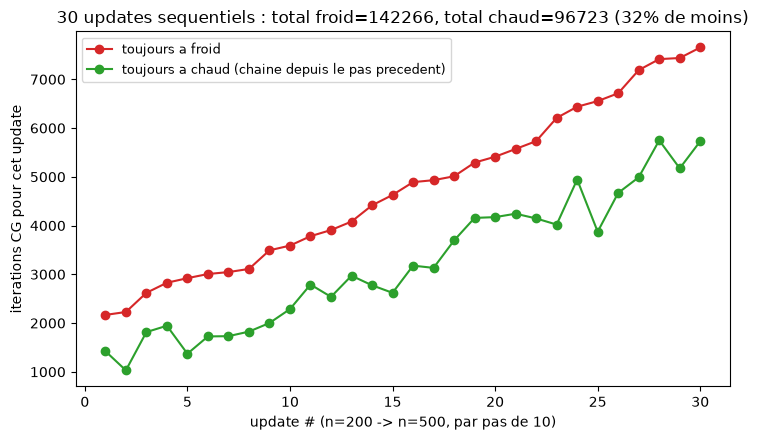

In [5]:

fig, ax = plt.subplots(figsize=(7.5, 4.5))
steps = list(range(1, n_batches + 1))
ax.plot(steps, per_step_cold, 'o-', color='tab:red', label='toujours a froid')
ax.plot(steps, per_step_warm, 'o-', color='tab:green', label='toujours a chaud (chaine depuis le pas precedent)')
ax.set_xlabel(f"update # (n={n_start} -> n={n_cur}, par pas de {batch})")
ax.set_ylabel("iterations CG pour cet update")
ax.set_title(f"{n_batches} updates sequentiels : total froid={total_cold}, total chaud={total_warm} "
             f"({100*(1-total_warm/total_cold):.0f}% de moins)")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


Réduction cumulée de **~32%** du nombre total d'itérations CG, et le
départ à chaud reste systématiquement sous le départ à froid à chaque étape
— c'est ce scénario, pas le sweep isolé du §2, qui reflète le mieux l'usage
réel de `update()`.

## 4. Implémentation C++

La validation numérique ci-dessus a été traduite directement dans le code
(déjà mergé au moment où ce notebook est publié) :

- **`LinearAlgebra::conjugateGradientBatched`** (`LinearAlgebra.cpp`,
  déclaration dans `LinearAlgebra.hpp`) : nouveau paramètre optionnel
  `const arma::mat* X0 = nullptr`, dernier de la liste (donc aucun appel
  existant n'a besoin de changer). `X0 == nullptr` reproduit exactement le
  comportement d'avant (`x0=0`). Quand fourni, initialise `Xc = *X0` et le
  résidu `R = B - AmulBatched(X0)` au lieu de `R = B` ; une colonne dont le
  résidu initial est déjà sous tolérance est marquée convergée avant même la
  première itération (cas `X0` déjà exact, testé explicitement dans
  `LinearAlgebraTest.cpp`).
- **`Kriging::_logLikelihoodIterative`** : deux nouveaux paramètres optionnels,
  `RinvFY_x0` (le warm start à utiliser pour le solve `R^-1*[F|y]`) et
  `RinvFY_out` (pour récupérer la solution et la mettre en cache). Les deux
  `nullptr` par défaut = comportement identique à avant.
- **`m_iterative_RinvFY_cache`** (nouveau membre de `Kriging`) : la dernière
  solution `R^-1*[F|y]` commise, écrite à chaque point de "commit" d'un fit
  ou d'un update `LLIterative` (3 endroits dans `Kriging.cpp`). Une taille de
  ligne qui ne correspond pas au `n` courant (cache absent ou périmé) signifie
  simplement "pas de démarrage à chaud disponible" -- comportement d'avant.
- **`Kriging::updateIterative`** : avant d'étendre `m_X`/`m_y`, capture
  `n_o = m_X.n_rows` ; si le cache est valide, construit
  `x0 = [m_iterative_RinvFY_cache ; zeros(n_u, ncols)]` et le passe au solve
  final ; met à jour le cache avec la nouvelle solution pour le prochain
  `update()`.

**Limites assumées** : le chemin GPU (`gpuCgSolve`) ignore silencieusement
`X0` pour l'instant (pas encore câblé dans les noyaux CUDA/HIP/SYCL/Metal) ;
la boucle BFGS interne d'un `update(refit=true)` n'utilise pas non plus ce
warm start pour ses évaluations intermédiaires (seul le solve **final**, après
que theta s'est stabilisé, en bénéficie) ; les probes Hutchinson, elles,
n'ont jamais de warm start pertinent puisqu'elles sont entièrement redessinées
à chaque update (nouveaux vecteurs aléatoires, sans rapport avec les anciens).

## 5. Conclusion

| | |
|---|---|
| Gain mesuré, update isolé | 76% (n_u=1) → ~0% (n_u≳n_o), décroissance régulière |
| Gain mesuré, 30 updates séquentiels | 32% cumulé sur le nombre total d'itérations CG |
| Coût en précision | Aucun -- même solution, à la tolérance CG près, quel que soit x0 |
| Brique nouvelle nécessaire | Un paramètre `X0` optionnel dans une fonction déjà existante |
| Statut | **Implémenté** : `LinearAlgebra::conjugateGradientBatched`, `Kriging::updateIterative` |
| Non couvert | Boucle BFGS interne du refit, backends GPU (warm start ignoré, pas d'erreur) |

Comme pour les deux autres notebooks de cette série, tous les nombres
ci-dessus proviennent de l'exécution réelle de ce notebook (graines fixées
dans le code).